In [1]:
from google.colab import drive
# drive.flush_and_unmount()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.read_csv('/content/drive/My Drive/music-recommendations/cleaned-data/audio_features.csv')

In [4]:
data.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'type', 'id', 'uri', 'track_href', 'analysis_url', 'duration_ms',
       'time_signature'],
      dtype='object')

In [5]:
music_features = data.drop(columns=['type', 'analysis_url', 'uri', 'track_href'])
music_features.dropna(inplace=True)

In [6]:
print(music_features.columns)

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'id', 'duration_ms', 'time_signature'],
      dtype='object')


In [7]:
music_features.shape

(2262190, 14)

In [8]:
# NULL Values
print(music_features.isnull().sum(axis = 0), "\n")
# None values
print(music_features.isna().sum(axis = 0), '\n')
print(music_features.dtypes)

danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
id                  0
duration_ms         0
time_signature      0
dtype: int64 

danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
id                  0
duration_ms         0
time_signature      0
dtype: int64 

danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
id                   object
duration_ms       

In [9]:
from sklearn import preprocessing
prepdf = music_features.drop(columns=['id'])
x = prepdf.values 
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
df = pd.DataFrame(x_scaled)
df.columns = prepdf.columns

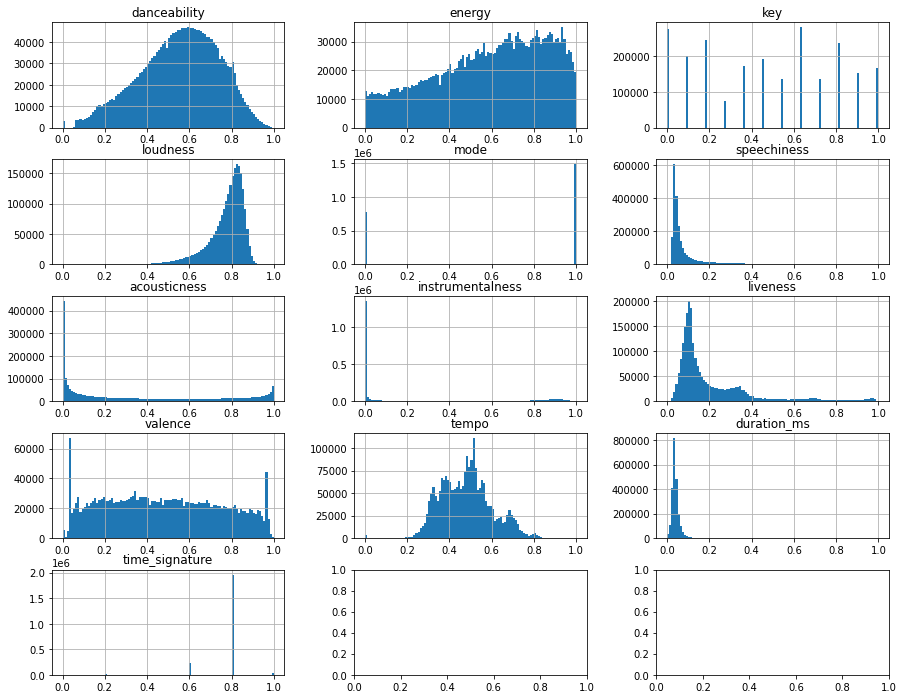

In [10]:
fig, axes = plt.subplots(len(df.columns)//3+1, 3, figsize=(15, 12))
i = 0
for triaxis in axes:
    for axis in triaxis:
        if i >= len(df.columns):
          break
        df.hist(column = df.columns[i], bins = 100, ax=axis)
        i = i+1
from google.colab import files
plt.savefig("distribution.png")
# files.download("distribution.png")

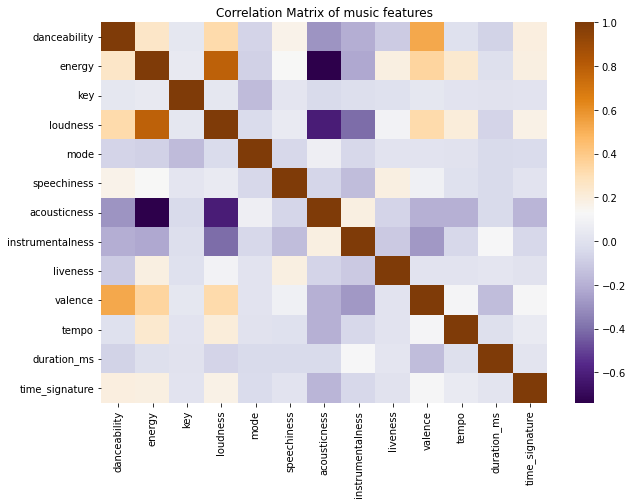

In [11]:
import seaborn as sns
# sns.color_palette("colorblind")
f = plt.figure(figsize=(10,7))
corrmat = df.corr()
sns.heatmap(corrmat, cmap='PuOr_r')
plt.title("Correlation Matrix of music features")
plt.savefig("correlation.png")
# files.download("correlation.png")
plt.show()

In [12]:
from sklearn.decomposition import PCA, FactorAnalysis
pca = PCA(n_components=2, svd_solver='full')
pca.fit(df)
print(pca.explained_variance_ratio_)

[0.28421971 0.24770494]


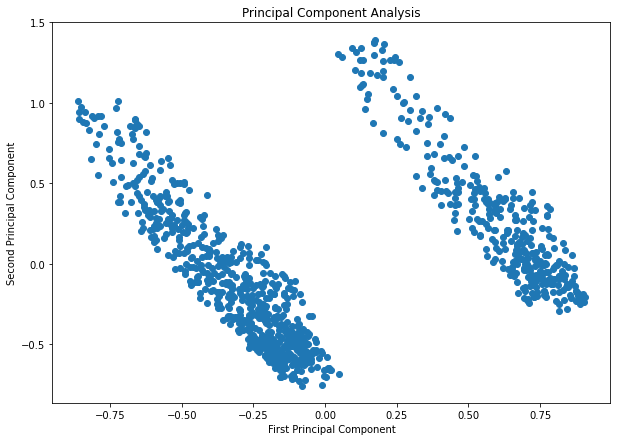

In [13]:
import matplotlib.cm as cm
Z = pca.fit_transform(df)
idx=np.random.choice(range(Z.shape[0]),1000)
f = plt.figure(figsize=(10,7))
plt.scatter(Z[idx,0], Z[idx,1])
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Principal Component Analysis")
plt.savefig("pca_scatter.png")
# files.download("pca_scatter.png")
plt.show()

In [14]:
from sklearn.cluster import KMeans
from tqdm import tqdm 
num_clusters = np.arange(1,15)
inertias = []
for k in tqdm(num_clusters):
  model = KMeans(n_clusters=k, init="k-means++")
  model.fit(Z)
  inertias.append(model.inertia_)


 50%|█████     | 7/14 [01:55<01:55, 16.43s/it]


KeyboardInterrupt: ignored

In [ ]:
f = plt.figure(figsize=(7,4))
plt.plot(num_clusters, inertias)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.savefig("elbow.png")
# files.download("elbow.png")
plt.show()

In [15]:
model = KMeans(n_clusters=2, init="k-means++")
y_pred = model.fit_predict(Z)

In [16]:
y_pred

array([0, 0, 1, ..., 0, 1, 0], dtype=int32)

In [17]:
cluster1 = df[y_pred==1]
cluster2 = df[y_pred==0]

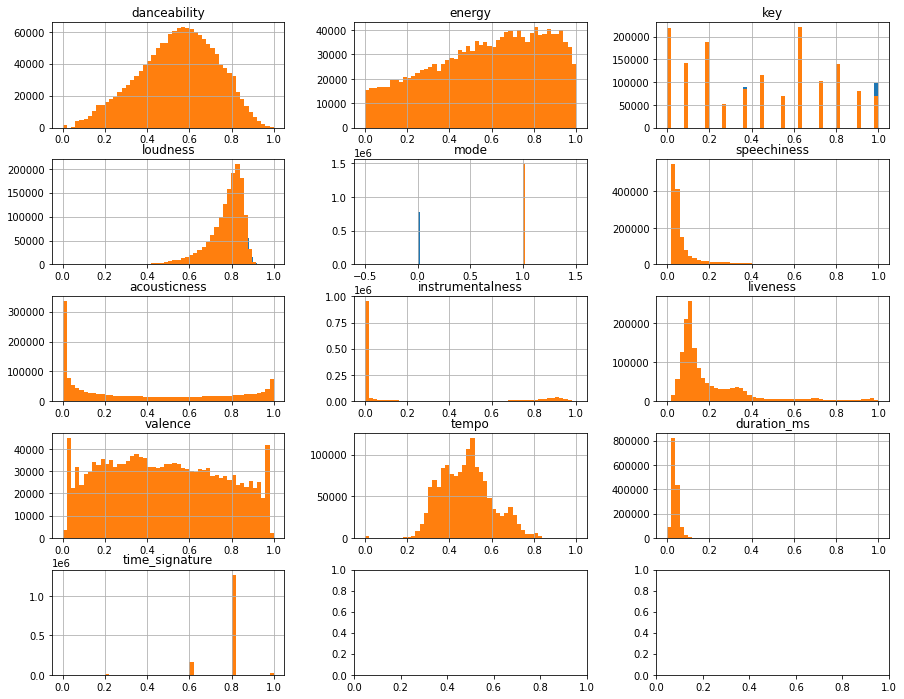

In [18]:
fig, axes = plt.subplots(len(cluster1.columns)//3+1, 3, figsize=(15, 12))
i = 0
for triaxis in axes:
    for axis in triaxis:
        if i >= len(cluster1.columns):
          break
        cluster2.hist(column = df.columns[i], bins = 50, ax=axis)
        cluster1.hist(column = df.columns[i], bins = 50, ax=axis)
        i = i+1
plt.savefig("kmeans_feat.png")
# files.download("kmeans_feat.png")

In [19]:
new_df = df.drop(columns=["mode"])
pca = PCA(n_components=2, svd_solver='full')
pca.fit(new_df)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.34831971 0.1809138 ]
0.5292335121344017


In [20]:
coefs = dict()
for j in range(2):
  coefs[j] = {}
  for i, col in enumerate(new_df.columns):
    coefs[j][col] = pca.components_[j,i]
coefs

{0: {'acousticness': 0.655717008463207,
  'danceability': -0.18316116547396238,
  'duration_ms': 0.00315807075959499,
  'energy': -0.48284900357159266,
  'instrumentalness': 0.42096487109065267,
  'key': -0.061771158750735015,
  'liveness': -0.058950816551553875,
  'loudness': -0.14517359511580705,
  'speechiness': -0.041151661149923906,
  'tempo': -0.05839732087332583,
  'time_signature': -0.043066310412920986,
  'valence': -0.3013270233208372},
 1: {'acousticness': -0.4540374499497593,
  'danceability': -0.05928688109274414,
  'duration_ms': 0.012062339816670532,
  'energy': 0.22872887563862893,
  'instrumentalness': 0.8184578824574824,
  'key': 0.14448300041093992,
  'liveness': -0.021713220265307503,
  'loudness': 0.0102270807166256,
  'speechiness': -0.040177637687050904,
  'tempo': 0.03385857003663492,
  'time_signature': 0.016066768873633636,
  'valence': -0.20863646590365512}}

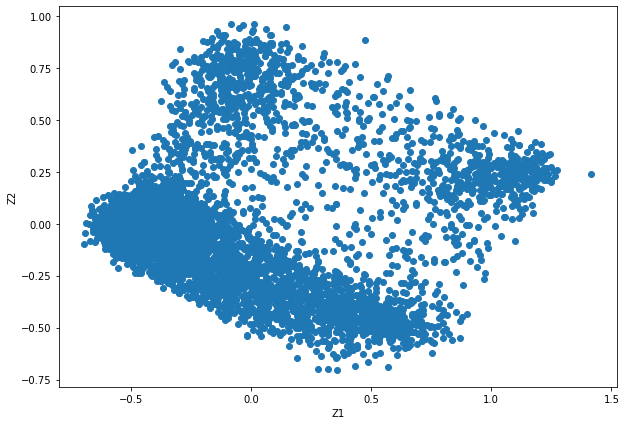

In [21]:
Z = pca.fit_transform(new_df)
idx=np.random.choice(range(Z.shape[0]),5000)
f = plt.figure(figsize=(10,7))
# plt.scatter(Z[:,0], Z[:,1])
plt.scatter(Z[idx,0], Z[idx,1])
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.savefig("scatter_new_pca.png")
# files.download("scatter_new_pca.png")

In [22]:
from sklearn.metrics import silhouette_score
num_clusters = np.arange(1,15)
inertias = []
for k in tqdm(num_clusters):
  model = KMeans(n_clusters=k, init="k-means++")
  model.fit(Z)
  inertias.append(model.inertia_)

  # score = silhouette_score(Z, model.labels_, metric='euclidean')
  # sscores.append(score)

 29%|██▊       | 4/14 [00:30<01:29,  8.91s/it]

KeyboardInterrupt: ignored

Exception ignored in: 'sklearn.cluster._k_means_common._relocate_empty_clusters_dense'
Traceback (most recent call last):
  File "<__array_function__ internals>", line 2, in where
KeyboardInterrupt


KeyboardInterrupt: ignored

Exception ignored in: 'sklearn.cluster._k_means_common._relocate_empty_clusters_dense'
Traceback (most recent call last):
  File "<__array_function__ internals>", line 2, in where
KeyboardInterrupt
 36%|███▌      | 5/14 [00:51<01:33, 10.34s/it]


KeyboardInterrupt: ignored

In [ ]:
f = plt.figure(figsize=(7,4))
plt.plot(num_clusters, inertias)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.savefig("elbow.png")
# files.download("elbow.png")
plt.show()

In [23]:
model = KMeans(n_clusters=3, init="k-means++")
model.fit(Z)

KMeans(n_clusters=3)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


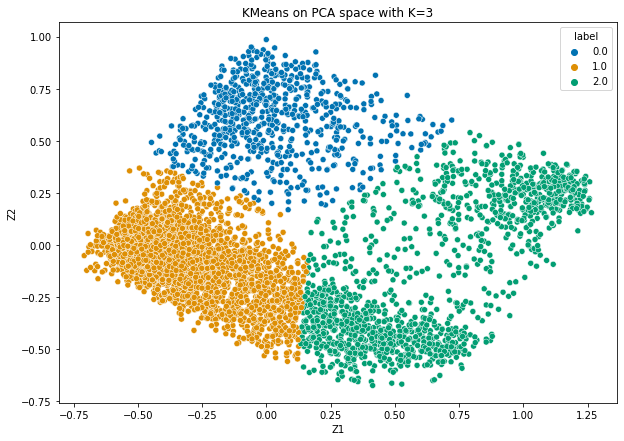

In [24]:
idx=np.random.choice(range(Z.shape[0]),5000)
clusters = pd.DataFrame(np.append(Z,model.labels_.reshape(-1,1),1), columns=["Z1","Z2","label"])
clusters = clusters.iloc[idx]
f = plt.figure(figsize=(10,7))
sns.scatterplot("Z1", "Z2", hue="label", palette='colorblind', data=clusters)
plt.title("KMeans on PCA space with K=3")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.savefig("scatter_kmeans_pca.png")
# files.download("scatter_kmeans_pca.png")
# clusters.plot.scatter("Z1", "Z2", c="label", colormap='PuOr_r')
plt.show()

In [25]:
cluster0 = clusters[clusters.label == 0.0].index
cluster1 = clusters[clusters.label == 1.0].index
cluster2 = clusters[clusters.label == 2.0].index
# cluster3 = clusters[clusters.label == 3].index

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

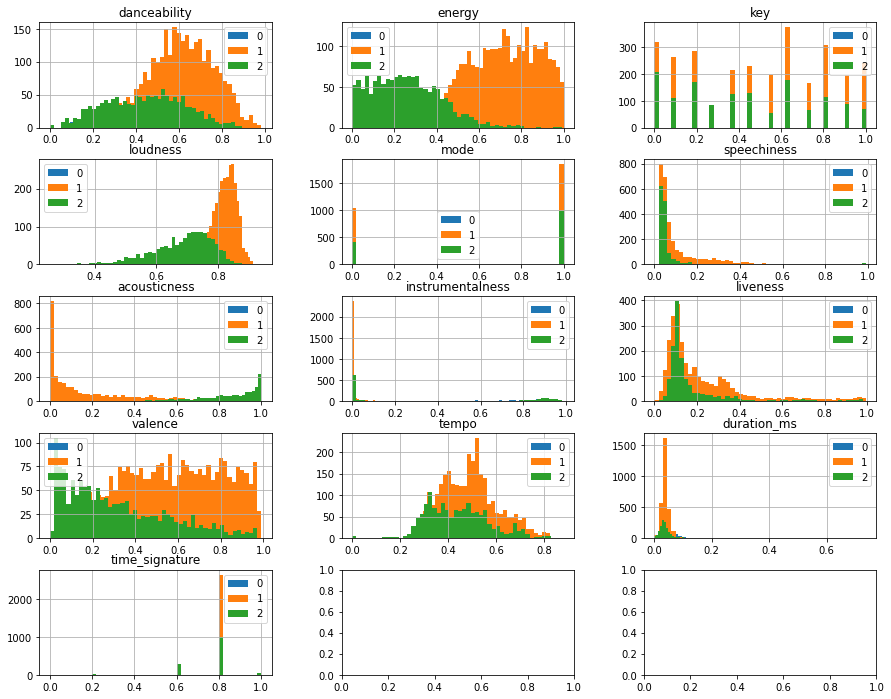

In [26]:
fig, axes = plt.subplots(len(df.columns)//3+1, 3, figsize=(15, 12))
i = 0
for triaxis in axes:
    for axis in triaxis:
        if i >= len(df.columns):
          break
        df.iloc[cluster0].hist(column = df.columns[i], bins = 50, ax=axis, label="0")
        df.iloc[cluster1].hist(column = df.columns[i], bins = 50, ax=axis, label="1")
        df.iloc[cluster2].hist(column = df.columns[i], bins = 50, ax=axis, label="2")
        # df.iloc[cluster3].hist(column = df.columns[i], bins = 50, ax=axis, label="3")
        i = i+1
        axis.legend()
plt.savefig("distribution_kmeans_pca.png")
# files.download("distribution_kmeans_pca.png")      
plt.show()

In [27]:
# import numpy as np
# from sklearn.datasets.samples_generator import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
# from matplotlib import pyplot as plt
# import seaborn as sns
# sns.set()

In [28]:
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(Z)
distances, indices = nbrs.kneighbors(Z)
distances = np.sort(distances, axis=0)
distances = distances[:,1]

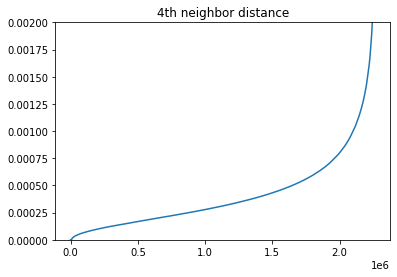

In [29]:
plt.ylim([0,0.002])
plt.plot(distances)
plt.title("4th neighbor distance")
plt.savefig("elbow_db.png")
# files.download("elbow_db.png")  

In [30]:
m = DBSCAN(eps=0.00075, min_samples=10)
m.fit(Z)

DBSCAN(eps=0.00075, min_samples=10)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


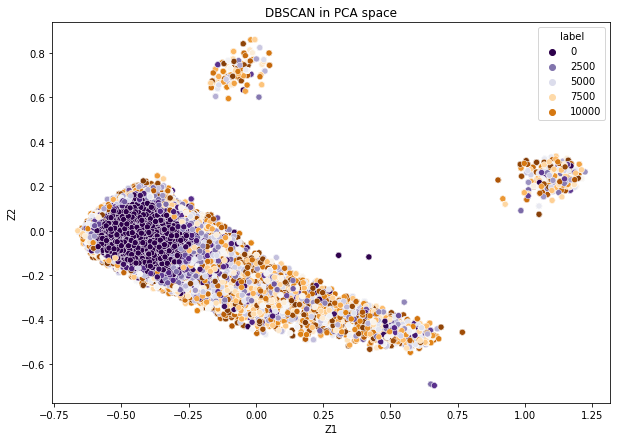

In [31]:
# idx=np.random.choice(range(Z.shape[0]),5000)
dbclust = pd.DataFrame(np.append(Z,m.labels_.reshape(-1,1),1), columns=["Z1","Z2","label"])
dbclust = dbclust[dbclust.label != -1]
f = plt.figure(figsize=(10,7))
sns.scatterplot("Z1", "Z2", hue="label", palette='PuOr_r', data=dbclust)
plt.title("DBSCAN in PCA space")
plt.savefig("dbscan.png")
# files.download("dbscan.png")  
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


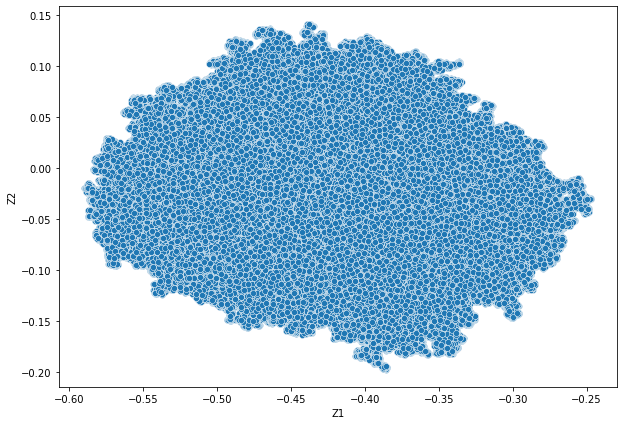

In [32]:
f = plt.figure(figsize=(10,7))
sns.scatterplot("Z1", "Z2", palette='PuOr_r', data=dbclust[dbclust.label==1])
plt.show()

In [33]:
dbclust0 = dbclust[dbclust.label == 1].index

In [34]:
print((len(dbclust0)-dbclust.shape[0])/dbclust.shape[0]*100)

-35.80984448446869


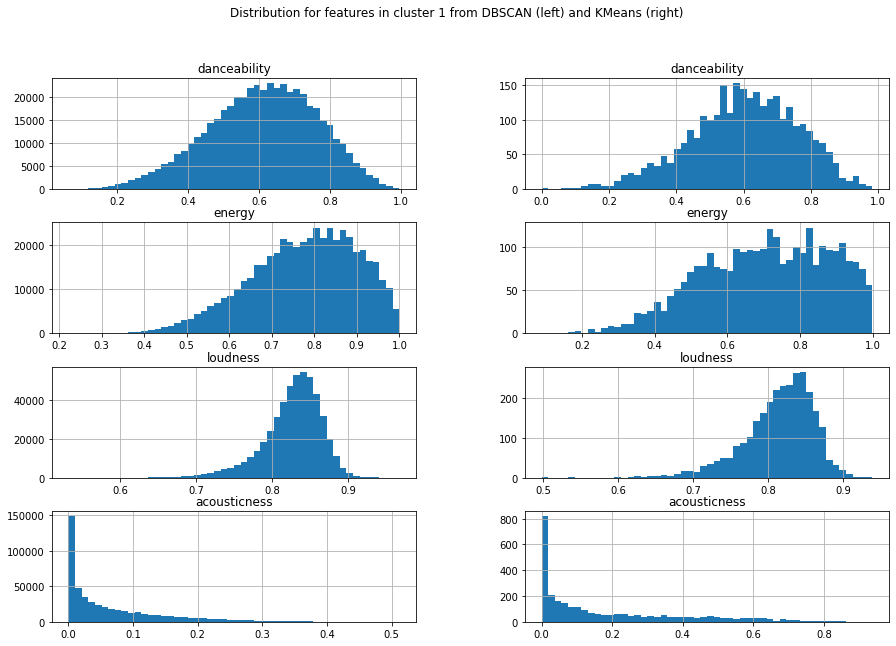

In [35]:
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
df.iloc[dbclust0].hist(column = "danceability", bins = 50, ax=axes[0,0], label='DBSCAN')
# axes[0,0].legend()
df.iloc[cluster1].hist(column = "danceability", bins = 50, ax=axes[0,1], label='KMEANS')
# axes[0,1].legend()

df.iloc[dbclust0].hist(column = "energy", bins = 50, ax=axes[1,0], label='DBSCAN')
# axes[1,0].legend()
df.iloc[cluster1].hist(column = "energy", bins = 50, ax=axes[1,1], label='KMEANS')
# axes[1,1].legend()

df.iloc[dbclust0].hist(column = "loudness", bins = 50, ax=axes[2,0], label='DBSCAN')
# axes[2,0].legend()
df.iloc[cluster1].hist(column = "loudness", bins = 50, ax=axes[2,1], label='KMEANS')
# axes[2,1].legend()

df.iloc[dbclust0].hist(column = "acousticness", bins = 50, ax=axes[3,0], label='DBSCAN')
# axes[3,0].legend()
df.iloc[cluster1].hist(column = "acousticness", bins = 50, ax=axes[3,1], label='KMEANS')
# axes[3,1].legend()
fig.suptitle("Distribution for features in cluster 1 from DBSCAN (left) and KMeans (right)")
plt.savefig("cluster1.png")
# files.download("cluster1.png")  

In [36]:
track_info = pd.read_csv('/content/drive/My Drive/music-recommendations/cleaned-data/tracks_information.csv')


In [37]:
track_info.head()

,id,album_id,album_name,artists_name,release_date,popularity,isrc_id,preview_url,track_name
0,3mehsYjucCaFAV58T8s0PH,5FT0npUfURRt57Tqb6sVe5,Embrace,Shah,2017-10-16,0,QZ9Y21744033,NaN,Embrace
1,1mSHzKgpqf0IsvRC6VMmYL,4sgNwlj2W0970HynDJdr0A,Good Luck,Robot Science,2011-01-22,7,TCAAU1150084,https://p.scdn.co/mp3-preview/303dde4663735d13...,Shine
2,1xPviikqPgiGgjssuWR2Rh,1omq1hEgiyw1KSoSXlBe90,Joel Faviere -Thunder,Sew Intricate,2012-10-07,16,TCABJ1280126,https://p.scdn.co/mp3-preview/271f43b0ecc61940...,White Mercedes
3,2qdvrUn0BDNTcXiU2BRGLv,3WUxwGfGYDMEFbQc6QlH1l,Three,Aevion,2013-01-21,0,QMSNZ1265309,NaN,Three - Original Mix
4,7izQwQZEvA9IsWVGOGVLja,1D0vUt1VNo5ps5u2R2IHj8,Respighi: Poema Autunnale / Concerto Gregorian...,"Ottorino Respighi,Lydia Mordkovitch,BBC Philha...",1993-11-01,0,GBLWD9313703,https://p.scdn.co/mp3-preview/c8199cc164993f53...,"Concerto gregoriano, P. 135: II. Andante espre..."


In [38]:
track_info['popularity'].min()

0

In [39]:
track_info['popularity'].max()


95

In [40]:
ids = music_features.iloc[dbclust0]['id']

In [41]:
ids

7          6nTsQhM0FtKvkZ7zyVf8Ci
11         37LV4Qu7tIkSQrOl6yn7Us
12         1uzXENkBTTt1Oex2nR0t1p
17         2OWPaYiXZUeLDF6sVXUtgT
18         4ZY1MKm7pbC2v19Lj02SSR
                    ...          
2262166    2cDx3NJJoxmWmtmi3o0nj9
2262168    5hFCF4OxN1q197xtfDCWfM
2262177    0cvEa8A2J4X4qnMcjwE1ZL
2262180    2YzhNDnZWmfqJge8SrId6e
2262187    0hbU2HMHdksfaIgp8ZoACV
Name: id, Length: 491470, dtype: object

In [42]:
df_filt = track_info[track_info.id.isin(ids)]

In [43]:
df_filt.sort_values('popularity', ascending=False).head(10)

,id,album_id,album_name,artists_name,release_date,popularity,isrc_id,preview_url,track_name
1029048,1SOClUWhOi8vHZYMz3GluK,6MuWCR3WPjwyKhqsTKLZ3z,Feel Something,Jaymes Young,2017-06-23,95,USAT21700859,https://p.scdn.co/mp3-preview/b211de9cfac2db97...,Infinity
1645888,2QjOHCTQ1Jl3zawyYOpxh6,4xkM0BwLM9H2IUcbYzpcBI,I Love You.,The Neighbourhood,2013-04-19,92,USSM11300080,https://p.scdn.co/mp3-preview/b189d26b94a514fa...,Sweater Weather
1777497,2eAvDnpXP5W0cVtiI0PUxV,6FgtuX3PtiB5civjHYhc52,Safe Haven,Ruth B.,2017-05-05,91,USSM11703468,https://p.scdn.co/mp3-preview/de039809a674d90a...,Dandelions
410564,7lQ8MOhq6IN2w8EYcFNSUk,2cWBwpqMsDJC1ZUwz813lo,The Eminem Show,Eminem,2002-05-26,89,USIR10211038,NaN,Without Me
1084794,79nEEoEPY2w8EXj9hjn5oc,09kU2R5DyHy86Ko8xXfkKK,Lavender,Yung Lean,2013-08-16,88,SEY491300006,https://p.scdn.co/mp3-preview/97a82573a9ec1193...,Ginseng Strip 2002
1684592,3yfqSUWxFvZELEM4PmlwIR,6t7956yu5zYf5A829XRiHC,The Marshall Mathers LP,Eminem,2000-05-23,88,USIR10000448,NaN,The Real Slim Shady
2161020,0ct6r3EGTcMLPtrXHDvVjc,0h2knr6qpiAq0tV5ri5JMF,The Days / Nights,Avicii,2014-01-01,88,CH3131340464,NaN,The Nights
1062002,6gBFPUFcJLzWGx4lenP6h2,42WVQWuf1teDysXiOupIZt,Birds In The Trap Sing McKnight,Travis Scott,2016-09-16,87,USSM11607555,https://p.scdn.co/mp3-preview/d6d1ec9bfc824637...,goosebumps
51384,6FE2iI43OZnszFLuLtvvmg,5IenxFp0vpnXBUxPcwJtbE,MKTO,MKTO,2012,86,USSM11301446,https://p.scdn.co/mp3-preview/2fabd6cedd99b5dc...,Classic
2163671,60a0Rd6pjrkxjPbaKzXjfq,6hPkbAV3ZXpGZBGUvL6jVM,Hybrid Theory (Bonus Edition),Linkin Park,2000-10-24,86,USWB10002407,https://p.scdn.co/mp3-preview/6ce8bcf317e8c562...,In The End


In [44]:
# fig, axes = plt.subplots(len(df.columns)//3+1, 3, figsize=(20, 15))
# i = 0
# for triaxis in axes:
#     for axis in triaxis:
#         if i >= len(df.columns):
#           break
#         df.iloc[dbclust0].hist(column = df.columns[i], bins = 50, ax=axis, label="0")
#         i += 1

In [45]:
 # from itertools import permutations
# pca = PCA(n_components=2)
# perm = permutations(df.columns, 5)
# output = set(map(lambda x: tuple(sorted(x)),perm))
# explained_var = {}
# for i, perm in enumerate(output):
#   pca.fit(df[list(perm)])
#   explained_var[perm] = pca.explained_variance_ratio_

In [46]:
# max = 0
# maxi = None
# for key, val in explained_var.items():
#   if val.sum() > max:
#     max = val.sum()
#     maxi = key

In [47]:
# pca = PCA(n_components=2)
# Z = pca.fit_transform(df[list(maxi)])
# plt.scatter(Z[:,0], Z[:,1])
# plt.show()

In [48]:
# df5 = df[list(maxi)]
# model = KMeans(n_clusters=2, init="k-means++")
# y_pred = model.fit_predict(df5)

In [49]:
# c1 = df5[y_pred == 0]
# c2 = df5[y_pred == 1]
# fig, axes = plt.subplots(len(maxi)//2, 3, figsize=(15, 7))
# i = 0
# for triaxis in axes:
#     for axis in triaxis:
#         c1.hist(column = c1.columns[i], bins = 50, ax=axis)
#         c2.hist(column = c2.columns[i], bins = 50, ax=axis)
#         i = i+1